In [2]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# Настройка пути к проекту
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"✅ Корень проекта добавлен в путь: {project_root}")

# Импорт из svetlanna
from svetlanna import elements
from svetlanna import Wavefront, SimulationParameters
from svetlanna import LinearOpticalSetup
from svetlanna.wavefront import Wavefront
from svetlanna.simulation_parameters import SimulationParameters
from LightPipes import *
print("✅ Все импорты успешны!")

✅ Корень проекта добавлен в путь: c:\Users\Tecno\OneDrive\Desktop\Мой маленький мир\Работа\Диссертация\Программирование\svetlanna\SVETlANNa
✅ Все импорты успешны!


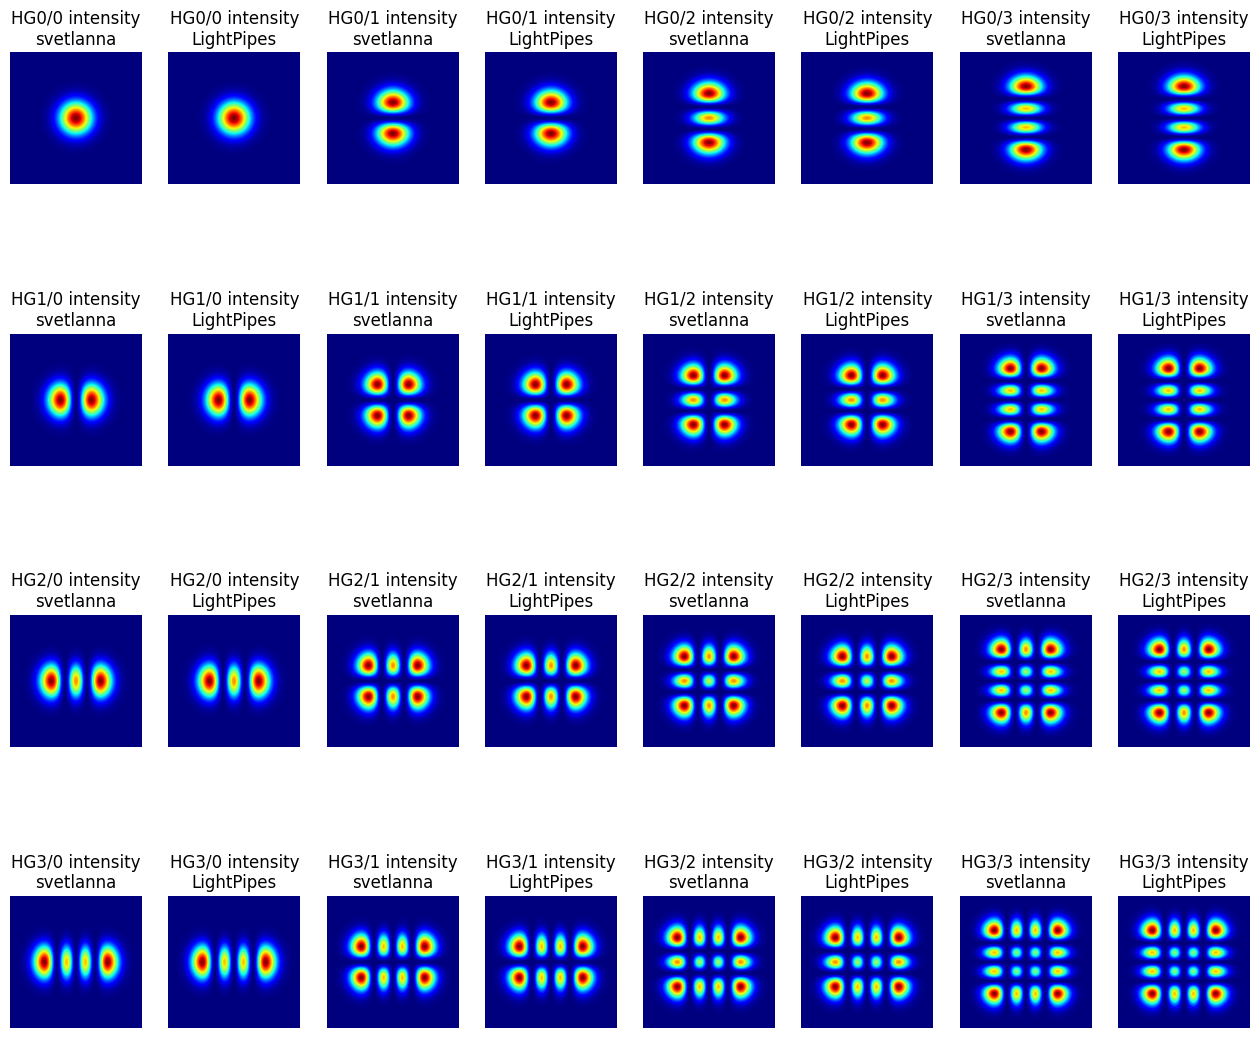

In [ ]:
# Визуализация мод в SVETlANNa и в LightPipes
#============Svetlana Part==================
wavelength = 500*10**(-9)
N = 2048
sim_params = SimulationParameters({
    "x": torch.linspace(-3, 3, N),
    "y": torch.linspace(-3, 3, N),
    "wavelength": wavelength,
})
waist = 1
distance = 1
modes=[]
for i in range(4):
    for k in range(4):
        modes.append((i,k))

fig, axes = plt.subplots(4,8, figsize = (16,14))
for idx, (m,n) in enumerate(modes):
    axs1 = axes[idx//4, (idx*2)%8]
    axs2 = axes[idx//4, (idx*2+1)%8]
    wf = Wavefront.hermite_gauss(
        sim_params,
        waist_radius=waist,
        distance=distance,
        m=m,
        n=n
    )
    #============LightPipes variant================
    size = 6
    F=Begin(size,wavelength,N)
    F=GaussHermite(F, waist, n=n, m=m)
    
    LP_intensity = Intensity(F)
    axs1.imshow(wf.intensity,cmap = 'jet')
    axs1.set_title(f'HG{m}/{n} intensity\nsvetlanna')
    axs1.axis('off')
    axs2.imshow(LP_intensity, cmap = 'jet')
    axs2.set_title(f'HG{m}/{n} intensity\nLightPipes')
    axs2.axis('off')
plt.show()


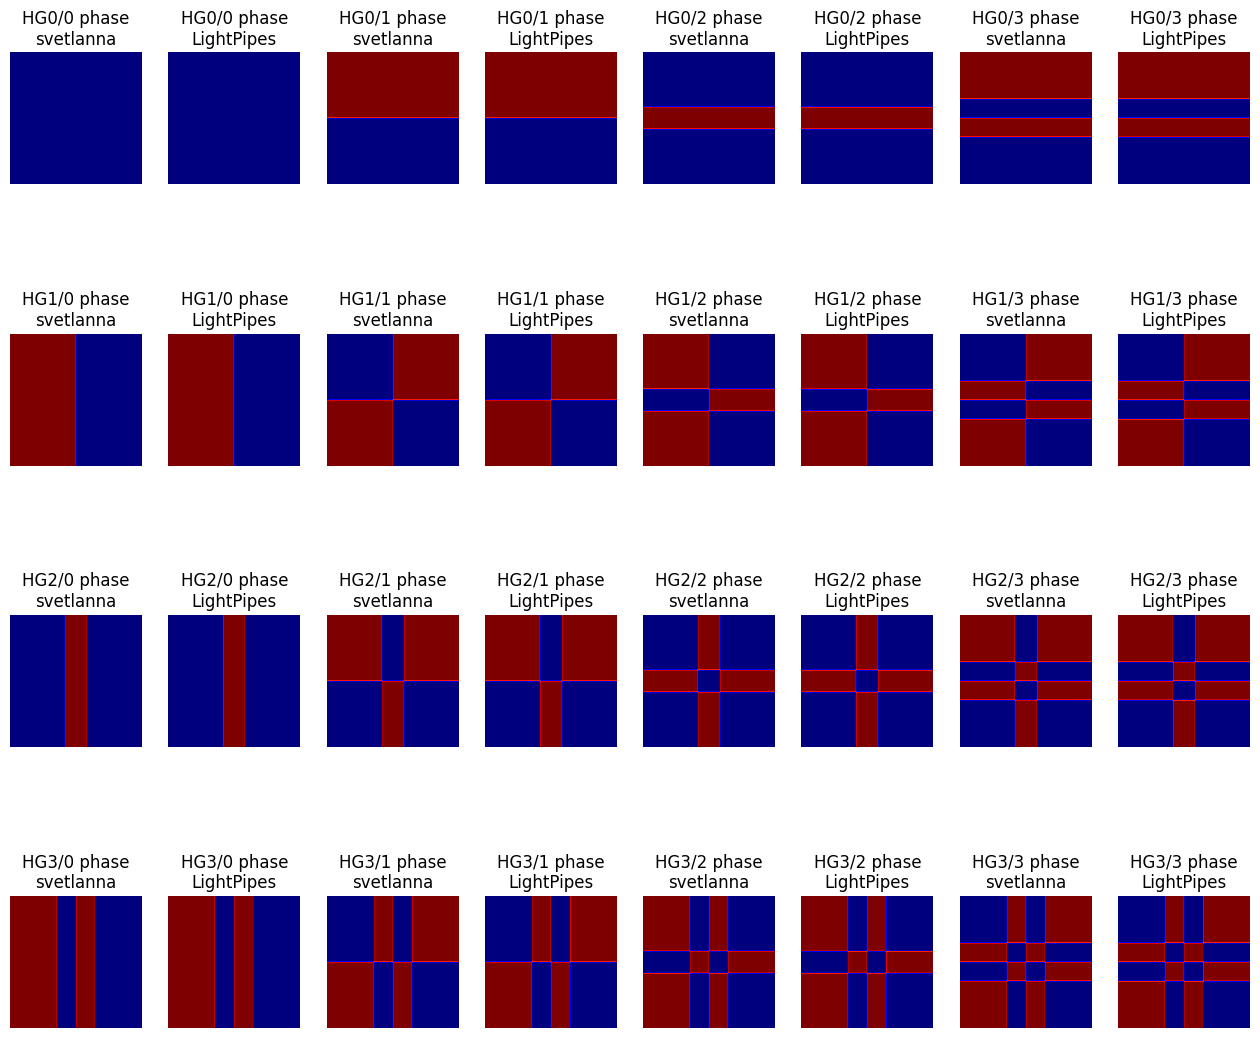

In [ ]:
#Визуализация фаз в SVETlANNa и LightPipes

distance = 0
fig, axes = plt.subplots(4,8, figsize = (16,14))
for idx, (m,n) in enumerate(modes):
    axs1 = axes[idx//4, (idx*2)%8]
    axs2 = axes[idx//4, (idx*2+1)%8]
    wf = Wavefront.hermite_gauss(
        sim_params,
        waist_radius=waist,
        distance=distance,
        m=m,
        n=n
    )
    #============LightPipes variant================
    size = 6
    F=Begin(size,wavelength,N)
    F=GaussHermite(F, waist, n=n, m=m)
    LP_phase = Phase(F)
    
    axs1.imshow(wf.phase,cmap = 'jet')
    axs1.set_title(f'HG{m}/{n} phase\nsvetlanna')
    axs1.axis('off')
    axs2.imshow(LP_phase, cmap = 'jet')
    axs2.set_title(f'HG{m}/{n} phase\nLightPipes')
    axs2.axis('off')
plt.show()

In [ ]:
#Численное сравнение профилей интенсивности через среднеквадратичное отклонение и через корреляцию

#=============Profile comparison==================

from scipy.stats import pearsonr
for idx, (m,n) in enumerate(modes):
    
    wf = Wavefront.hermite_gauss(
        sim_params,
        waist_radius=waist,
        distance=distance,
        m=m,
        n=n
    )
    intensity_sv = wf.intensity.cpu().numpy()
    phase_sv = wf.phase.cpu().numpy()
    size = 6
    F=Begin(size,wavelength,N)
    F=GaussHermite(F, waist, n=n, m=m)
    LP_phase = Phase(F)
    LP_intensity = Intensity(F)

    mse = np.mean((intensity_sv - LP_intensity)**2)
    mse_percent = (mse / intensity_sv.max()) * 100
    I1_flat = intensity_sv.flatten()
    I2_flat = LP_intensity.flatten()

    corr, _ = pearsonr(I1_flat, I2_flat)
    print(f"Корреляция интенсивности для моды ({m},{n}): {corr:.4f}") #Чем ближе к 1, тем лучше
    print(f"СКО интенсивности для моды ({m},{n}) в %= {mse_percent:.2f}") #Чем ближе к 0, тем лучше (указано в % от максимальной интенсивности в svetlanna)

Корреляция интенсивности для моды (0,0): 1.0000
СКО интенсивности для моды (0,0) в %= 0.00
Корреляция интенсивности для моды (0,1): 1.0000
СКО интенсивности для моды (0,1) в %= 0.00
Корреляция интенсивности для моды (0,2): 1.0000
СКО интенсивности для моды (0,2) в %= 0.00
Корреляция интенсивности для моды (0,3): 1.0000
СКО интенсивности для моды (0,3) в %= 0.00
Корреляция интенсивности для моды (1,0): 1.0000
СКО интенсивности для моды (1,0) в %= 0.00
Корреляция интенсивности для моды (1,1): 1.0000
СКО интенсивности для моды (1,1) в %= 0.00
Корреляция интенсивности для моды (1,2): 1.0000
СКО интенсивности для моды (1,2) в %= 0.00
Корреляция интенсивности для моды (1,3): 1.0000
СКО интенсивности для моды (1,3) в %= 0.01
Корреляция интенсивности для моды (2,0): 1.0000
СКО интенсивности для моды (2,0) в %= 0.00
Корреляция интенсивности для моды (2,1): 1.0000
СКО интенсивности для моды (2,1) в %= 0.00
Корреляция интенсивности для моды (2,2): 1.0000
СКО интенсивности для моды (2,2) в %= 0.00

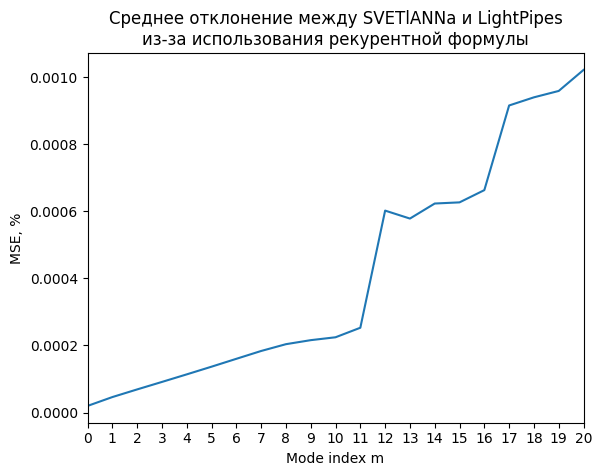

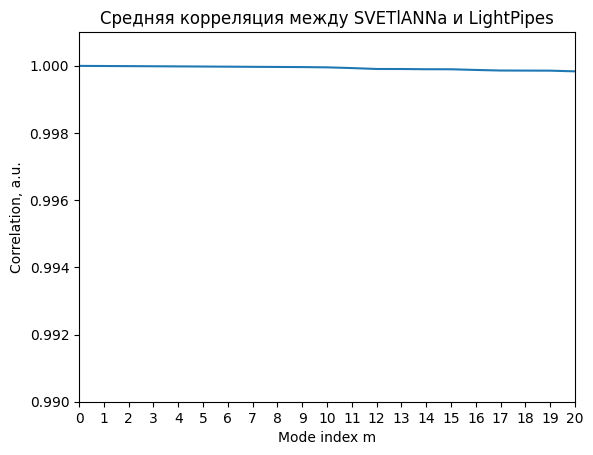

In [ ]:
# Ожидается, что использованный рекуррентный метод должен давать возрастающую ошибку для старших мод
# Проводится аналогичная оценка СКО и корреляции для случая изменения одного из модальных индексов
n=0
result_mse = []
result_corr = []
for m in range(21):
    
    wf = Wavefront.hermite_gauss(
        sim_params,
        waist_radius=waist,
        distance=distance,
        m=m,
        n=n
    )
    intensity_sv = wf.intensity.cpu().numpy()
    phase_sv = wf.phase.cpu().numpy()
    size = 6
    F=Begin(size,wavelength,N)
    F=GaussHermite(F, waist, n=n, m=m)
    LP_phase = Phase(F)
    LP_intensity = Intensity(F)

    
    I1_norm = intensity_sv / intensity_sv.max()
    I2_norm = LP_intensity / LP_intensity.max()

    
    mse_normalized = np.mean((I1_norm - I2_norm)**2)
    mse_percent = mse_normalized * 100
    result_mse.append(mse_percent)
    I1_flat = intensity_sv.flatten()
    I2_flat = LP_intensity.flatten()

    corr, _ = pearsonr(I1_flat, I2_flat)
    result_corr.append(corr.astype(float))

plt.plot(range(21), result_mse)
plt.title("Среднее отклонение между SVETlANNa и LightPipes\nиз-за использования рекурентной формулы")
plt.xticks(range(len(result_mse)))
plt.xlim((0,20))
plt.xlabel("Mode index m")
plt.ylabel("MSE, %")

plt.show()

plt.plot(range(21), result_corr)
plt.title("Средняя корреляция между SVETlANNa и LightPipes")
plt.xlabel("Mode index m")
plt.xticks(range(len(result_corr)))
plt.xlim((0,20))
plt.ylabel("Correlation, a.u.")
plt.ylim((0.99,1.001))
plt.show()

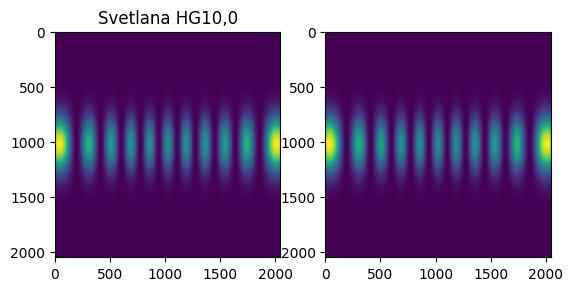

C:\Users\Tecno\AppData\Local\Temp\ipykernel_8632\3219584144.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  difference = wf.intensity[500,:]-LP_intensity[500,:]


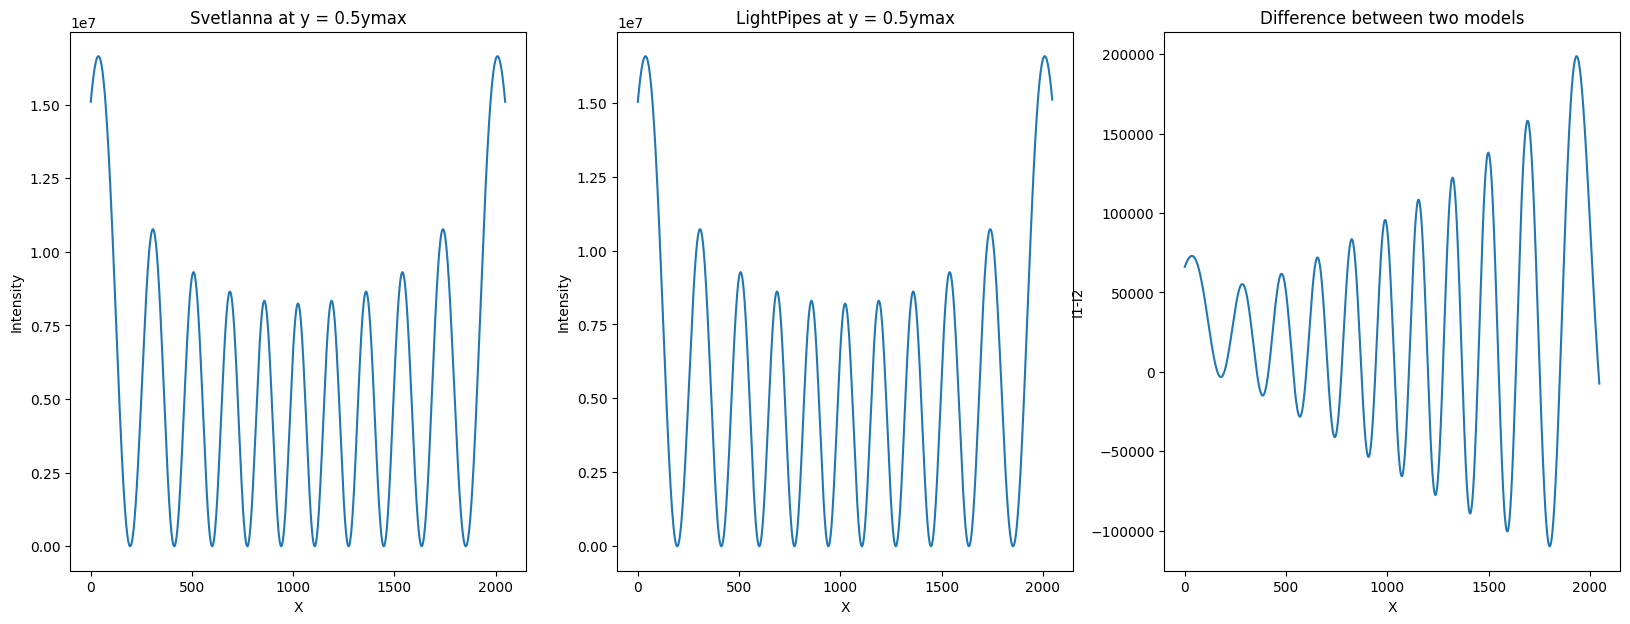

In [ ]:
# Сравнение профилей интенсивности и их отличий для одной из старших мод
# Графики: распределение интенсивности вдоль оси Ox и график их разницы
m=10
n=0
wf = Wavefront.hermite_gauss(
    sim_params,
    waist_radius=waist,
    distance=distance,
    m=m,
    n=n
)
intensity_sv = wf.intensity.cpu().numpy()
phase_sv = wf.phase.cpu().numpy()
size = 6
F=Begin(size,wavelength,N)
F=GaussHermite(F, waist, n=0, m=10)
LP_phase = Phase(F)
LP_intensity = Intensity(F)
fig, axes = plt.subplots(1,2)
axes[0].imshow(wf.intensity, label = "SVETlANNa")
axes[0].set_title(f"Svetlana HG{m},{n}")
axes[1].imshow(LP_intensity, label = "LightPipes cut at y = 0.5ymax")

plt.show()
difference = wf.intensity[500,:]-LP_intensity[500,:]
fig, axes = plt.subplots(1,3, figsize = (20,7))
axes[0].plot(wf.intensity[500,:], label = "SVETlANNa")
axes[0].set_ylabel("Intensity")
axes[0].set_xlabel("X")
axes[0].set_title("Svetlanna at y = 0.5ymax" )
axes[1].plot(LP_intensity[500,:], label = "LightPipes")
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("X")
axes[1].set_title("LightPipes at y = 0.5ymax" )
axes[2].plot(difference, label = "Difference between two modes")
axes[2].set_title("Difference between two models")
axes[2].set_ylabel("I1-I2")
axes[2].set_xlabel("X")
plt.show()


c:\Users\Tecno\OneDrive\Desktop\Мой маленький мир\Работа\Диссертация\Программирование\svetlanna\SVETlANNa\svetlanna\elements\free_space.py:159: UserWarning: The paraxial (near-axis) optics condition required for the Fresnel method is not satisfied. Consider increasing the distance or decreasing the screen size.
  warn(


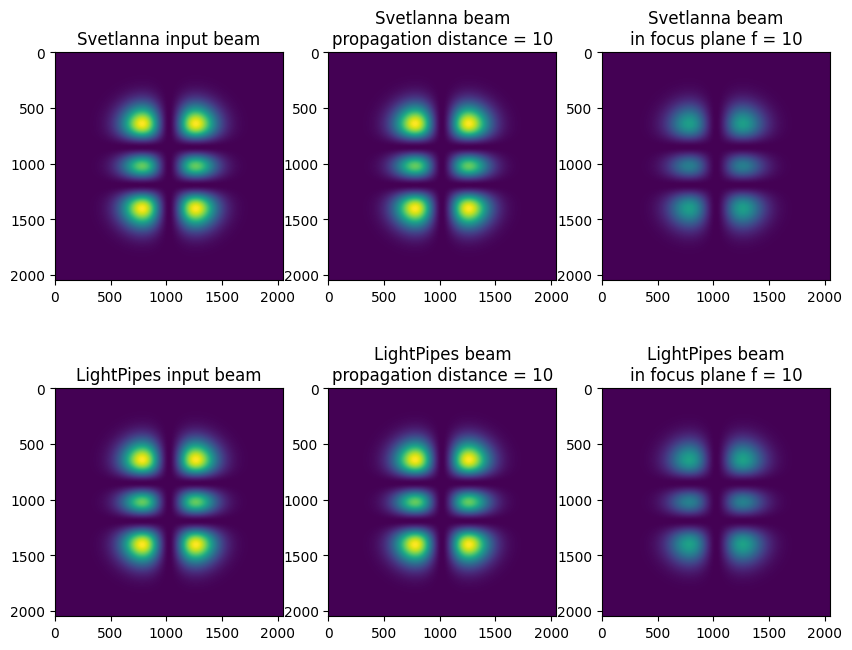

In [ ]:
# Визуальная оценка прохождения сквозь оптическую систему
m=1
n=2
f = 10
r = 100
#============Svetlana propagation==========
wf = Wavefront.hermite_gauss(
    sim_params,
    waist_radius=waist,
    distance=0,
    m=m,
    n=n
)
input_wf = wf.intensity
free_space = elements.FreeSpace(
    simulation_parameters=sim_params,
    distance = f,
    method="fresnel"
)
propagation_wf = free_space.forward(incident_wavefront=wf)
propagation_wf=propagation_wf.intensity
lens = elements.ThinLens(
    simulation_parameters=sim_params,
    focal_length=f,
    radius=r
)
setup = LinearOpticalSetup([free_space, lens, free_space])
focused_beam = setup.forward(wf)

#===============LightPipes propagation=================
F=Begin(size,wavelength,N)
F=GaussHermite(F, waist, n=n, m=m)
F_in = F
F_prop = Forvard(Fin = F, z = f)
F = Lens(Fin = F_prop, f=f)
F_focused = Forvard(Fin=F, z = f)

fig, axes = plt.subplots(2,3,figsize=(10,8))
axes[0,0].imshow(input_wf)
axes[0,0].set_title("Svetlanna input beam")
axes[0,1].imshow(propagation_wf)
axes[0,1].set_title(f"Svetlanna beam\npropagation distance = {f}")
axes[0,2].imshow(focused_beam.intensity)
axes[0,2].set_title(f"Svetlanna beam\nin focus plane f = {f}")

axes[1,0].imshow(Intensity(F_in))
axes[1,0].set_title("LightPipes input beam")
axes[1,1].imshow(Intensity(F_prop))
axes[1,1].set_title(f"LightPipes beam\npropagation distance = {f}")
axes[1,2].imshow(Intensity(F_focused))
axes[1,2].set_title(f"LightPipes beam\nin focus plane f = {f}")

plt.show()

In [ ]:
#Проверка совпадения результатов lightpipes и svetlanna при прохождении сетапа из апертуры и линзы для различных расстояний
#Рассматриваются два метода "fresnel" и "AS"
m=1
n=1
radius = 1
x = np.linspace(0.01,10,101)
mse_as=[]
mse_fr=[]
corr_as=[]
corr_fr=[]
wf = Wavefront.hermite_gauss(
    sim_params,
    waist_radius=waist,
    distance=0,
    m=m,
    n=n
)
def svetlana_propagation(distance):
    lens = elements.ThinLens(
    simulation_parameters=sim_params,
    focal_length=distance,
    radius=r
    )
    free_space_fr = elements.FreeSpace(
    simulation_parameters=sim_params,
    distance = distance,
    method="fresnel"
    )
    free_space_as =  elements.FreeSpace(
    simulation_parameters=sim_params,
    distance = distance,
    method="AS"
    )
    apert = elements.RoundAperture(simulation_parameters=sim_params, radius=radius)
    setup_fr = LinearOpticalSetup([apert, free_space_fr, lens, free_space_fr])
    setup_as = LinearOpticalSetup([apert, free_space_as, lens, free_space_as])
    wf_fr = setup_fr.forward(input_wavefront=wf)
    wf_as = setup_as.forward(input_wavefront=wf)
    return wf_fr, wf_as

def LightPipes_prop(distance):
    F=Begin(size,wavelength,N)
    F=GaussHermite(F, waist, n=n, m=m)
    F=CircAperture(F,radius)
    F = Forvard(Fin = F, z = distance)
    F = Lens(Fin = F, f=distance)
    F_focused = Forvard(Fin=F, z = distance)
    return F_focused

for distance in x:
    wf_fr, wf_as = svetlana_propagation(distance=distance)
    wf_lp = LightPipes_prop(distance=distance)

    wf_fr=wf_fr.intensity.cpu().numpy()
    wf_as = wf_as.intensity.cpu().numpy()
    wf_lp = Intensity(wf_lp)

    Ias_norm = wf_fr / wf_fr.max()
    Ifr_norm = wf_as /wf_as.max()
    Ilp_norm = wf_lp / wf_lp.max()

    
    mse_as_normalized = np.mean((Ias_norm - Ilp_norm)**2)
    mse_as_percent = mse_as_normalized * 100
    mse_as.append(mse_as_percent)

    mse_fr_normalized = np.mean((Ifr_norm - Ilp_norm)**2)
    mse_fr_percent = mse_fr_normalized * 100
    mse_fr.append(mse_fr_percent)
    I_as_flat = wf_as.flatten()
    I_fr_flat = wf_fr.flatten()
    I_lp_flat = wf_lp.flatten()

    corr_as1, _ = pearsonr(I_as_flat, I_lp_flat)
    corr_fr1,_ = pearsonr(I_fr_flat, I_lp_flat)
    corr_as.append(corr_as1.astype(float))
    corr_fr.append(corr_fr1.astype(float))





c:\Users\Tecno\OneDrive\Desktop\Мой маленький мир\Работа\Диссертация\Программирование\svetlanna\SVETlANNa\svetlanna\elements\free_space.py:142: UserWarning: Aliasing problems may occur in the AS method. Consider reducing the distance or increasing the Nx*dx product.
  warn(
c:\Users\Tecno\OneDrive\Desktop\Мой маленький мир\Работа\Диссертация\Программирование\svetlanna\SVETlANNa\svetlanna\elements\free_space.py:148: UserWarning: Aliasing problems may occur in the AS method. Consider reducing the distance or increasing the Ny*dy product.
  warn(


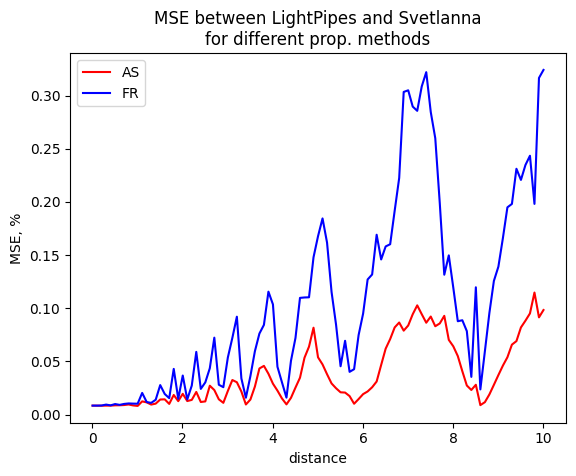

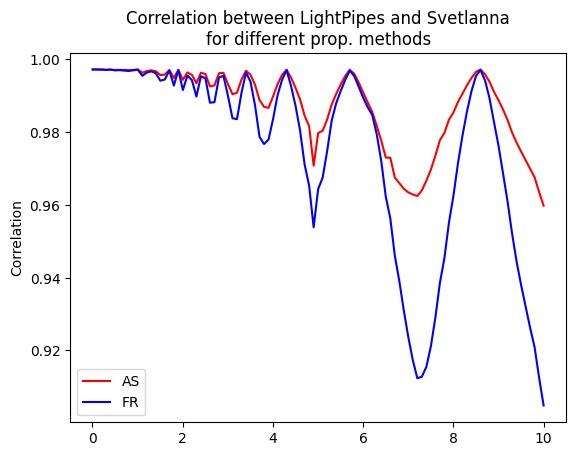

In [ ]:
#Оценка СКО и корреляции между интенсивностями, при расчёте прохождения системы апертура + линза. Сравнение между результатами LightPipes и Svetlanna
#Оценка проведена для методов AS и fresnel

plt.plot(np.linspace(0.01,10,101), mse_as, label="AS", color = "red")
plt.plot(np.linspace(0.01,10,101), mse_fr, label="FR", color = "blue")
plt.title("MSE between LightPipes and Svetlanna\nfor different prop. methods")
plt.xlabel("distance")
plt.ylabel("MSE, %")
plt.legend()
plt.show()
plt.plot(np.linspace(0.01,10,101), corr_as, label="AS", color = "red")
plt.plot(np.linspace(0.01,10,101), corr_fr, label="FR", color = "blue")
plt.title("Correlation between LightPipes and Svetlanna\nfor different prop. methods")
plt.ylabel("Correlation")
plt.legend()
plt.show()